# CLV Modeling with Statistical and Hybrid Approaches


## Modeling Pipeline (Hybrid)

This notebook implements a dual modeling strategy for Customer Lifetime Value (CLV) prediction:
###  Hybrid Model
- Uses both engineered features and `CLV_BGNBD` as inputs.
- Pros: Leverages probabilistic models to capture customer purchase behavior.

.



##  Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Lifetime CLV modeling
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap

import warnings
warnings.filterwarnings('ignore')

c:\Users\aufaa\finale\finale_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  Load Dataset

In [6]:
df = pd.read_excel("Supermarket Transactions.xlsx",sheet_name="Data")
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

##  Preprocessing

In [7]:
# Drop NA, duplicates, fix types
df = df.drop_duplicates()
df = df.dropna()

# Add total price per transaction
# df['TotalPrice'] = df['Units_Sold'] * df['Unit_Pric']

##  Hypothesis Testing

In [8]:
def income_avg(income_range):
    try:
        # Remove $ and K and split by dash
        cleaned = income_range.replace('$', '').replace('K', '').replace(',', '').strip()
        numbers = cleaned.split('-')

        # If it's a range, take average
        if len(numbers) == 2:
            return (int(numbers[0]) + int(numbers[1])) / 2 * 1000
        # If it's a single number (e.g., "85"), just return that
        elif len(numbers) == 1:
            return int(numbers[0]) * 1000
    except:
        return np.nan  # If it fails, return NaN

# Apply the fixed function
df['Income_Avg'] = df['Annual Income'].apply(income_avg)


##  RFM + Summary Data

In [9]:
rfm = summary_data_from_transaction_data(df, 'Customer ID', 'Purchase Date', monetary_value_col='Revenue', observation_period_end=df['Purchase Date'].max())
rfm = rfm.rename(columns={
    'frequency': 'frequency',
    'recency': 'recency',
    'T': 'T',
    'monetary_value': 'monetary_value'
})

##  BG/NBD + Gamma-Gamma Modeling

In [10]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])

ggf = GammaGammaFitter(penalizer_coef=0.01)
rfm_monetary = rfm[rfm['monetary_value'] > 0].copy()
ggf.fit(rfm_monetary['frequency'], rfm_monetary['monetary_value'])

rfm_monetary['Expected_Avg_Profit'] = ggf.conditional_expected_average_profit(
    rfm_monetary['frequency'], rfm_monetary['monetary_value']
)

rfm_monetary['CLV_BGNBD'] = ggf.customer_lifetime_value(
    bgf,
    rfm_monetary['frequency'],
    rfm_monetary['recency'],
    rfm_monetary['T'],
    rfm_monetary['monetary_value'],
    time=3,
    discount_rate=0.01,
    freq='D'
)

rfm = rfm.merge(rfm_monetary[['CLV_BGNBD']], left_index=True, right_index=True, how='left')

##  Feature Engineering

In [11]:
features = df.groupby('Customer ID').agg({
    'Units Sold': 'sum',
    'Children': 'first',
    'Income_Avg': 'first',
    'Revenue': 'sum'
}).reset_index()

xdata = rfm.reset_index().merge(features, on='Customer ID')

##  Heatmap

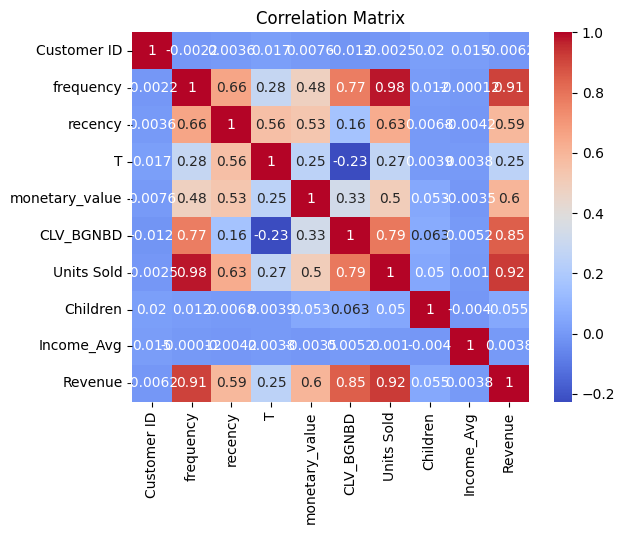

In [12]:
sns.heatmap(xdata.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

##  ML Models on BGNBD CLV

In [13]:
# Check for and drop rows with NaN in features or target
ml_data = xdata.drop(columns=['Customer ID'])
ml_data = ml_data.dropna(subset=['CLV_BGNBD'])  # if using hybrid CLV as target

X = ml_data.drop(columns=['CLV_BGNBD'])  # or the relevant CLV column
y = ml_data['CLV_BGNBD']

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])

# Final split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### XGBoost

In [14]:
xgb_model = xgb.XGBRegressor(n_estimators=200)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost RMSE:", mean_squared_error(y_test, xgb_preds))
print("XGBoost R²:", r2_score(y_test, xgb_preds))


XGBoost RMSE: 1.4942036073731202
XGBoost R²: 0.9581595049639345


### LightGBM

In [15]:
lgb_model = lgb.LGBMRegressor(n_estimators=200)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
print("LightGBM RMSE:", mean_squared_error(y_test, lgb_preds))
print("LightGBM R²:", r2_score(y_test, lgb_preds))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1113
[LightGBM] [Info] Number of data points in the train set: 2492, number of used features: 8
[LightGBM] [Info] Start training from score 6.278617
LightGBM RMSE: 1.1450225933697649
LightGBM R²: 0.9679372262938815


### CatBoost

In [16]:
cat_model = CatBoostRegressor(verbose=0)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)
print("CatBoost RMSE:", mean_squared_error(y_test, cat_preds))
print("CatBoost R²:", r2_score(y_test, cat_preds))

CatBoost RMSE: 0.8359449341381158
CatBoost R²: 0.9765919787004664


##  SHAP for XGBoost

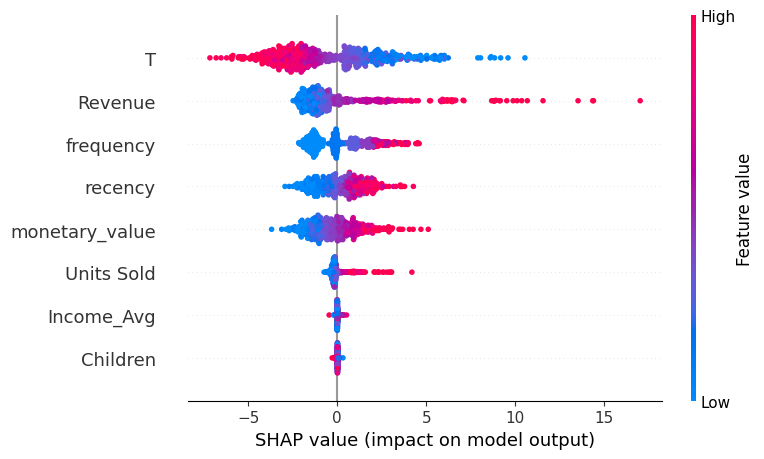

In [17]:
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

##  Compare All CLVs

In [18]:
# 1. Create X again for predictions, same preprocessing as during training
X_pred = xdata.drop(columns=['Customer ID', 'CLV_BGNBD'], errors='ignore')
X_pred = X_pred.select_dtypes(include=[np.number])
X_pred = X_pred.dropna()

# 2. Predict
xgb_preds = xgb_model.predict(X_pred)
lgb_preds = lgb_model.predict(X_pred)
cat_preds = cat_model.predict(X_pred)

# 3. Assign predictions only to rows in xdata that match X_pred
xdata.loc[X_pred.index, 'CLV_XGBoost'] = xgb_preds
xdata.loc[X_pred.index, 'CLV_LightGBM'] = lgb_preds
xdata.loc[X_pred.index, 'CLV_CatBoost'] = cat_preds


##  Save Final CSV

In [19]:
xdata.to_csv("Final_Clv_All_Models.csv", index=False)
print("Saved: Final_Clv_All_Models.csv")

Saved: Final_Clv_All_Models.csv


In [20]:
# Add recency to xdata from RFM table
xdata = xdata.merge(rfm[['recency']], left_on='Customer ID', right_index=True, how='left')


In [21]:
# Temporal split based on 80% cutoff in time
cutoff_date = df['Purchase Date'].quantile(0.8)

train_customers = df[df['Purchase Date'] <= cutoff_date]['Customer ID'].unique()
test_customers = df[df['Purchase Date'] > cutoff_date]['Customer ID'].unique()

X_train = xdata[xdata['Customer ID'].isin(train_customers)].drop(columns=['Customer ID', 'CLV_BGNBD'], errors='ignore')
y_train = xdata[xdata['Customer ID'].isin(train_customers)]['CLV_BGNBD']

X_test = xdata[xdata['Customer ID'].isin(test_customers)].drop(columns=['Customer ID', 'CLV_BGNBD'], errors='ignore')
y_test = xdata[xdata['Customer ID'].isin(test_customers)]['CLV_BGNBD']


In [22]:
from sklearn.cluster import KMeans

# Fill missing CLV with 0 before clustering
clv_for_cluster = xdata[['CLV_BGNBD']].fillna(0)

# 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
xdata['Segment'] = kmeans.fit_predict(clv_for_cluster)


In [23]:
# Predict expected orders in next 90 days
rfm['expected_orders_90D'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,  # future time window in days
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)


In [24]:
# Expected average order value
rfm['expected_aov'] = ggf.conditional_expected_average_profit(
    rfm['frequency'],
    rfm['monetary_value']
)
rfm['expected_revenue_90D'] = rfm['expected_orders_90D'] * rfm['expected_aov']

Correlation between models and probabilistic CLV:
                   Customer ID  CLV_XGBoost  CLV_LightGBM  CLV_CatBoost  \
Customer ID           1.000000    -0.005343     -0.005524     -0.005671   
CLV_XGBoost          -0.005343     1.000000      0.997493      0.998143   
CLV_LightGBM         -0.005524     0.997493      1.000000      0.998255   
CLV_CatBoost         -0.005671     0.998143      0.998255      1.000000   
CLV_Probabilistic    -0.012367     0.954929      0.952479      0.952512   

                   CLV_Probabilistic  
Customer ID                -0.012367  
CLV_XGBoost                 0.954929  
CLV_LightGBM                0.952479  
CLV_CatBoost                0.952512  
CLV_Probabilistic           1.000000  


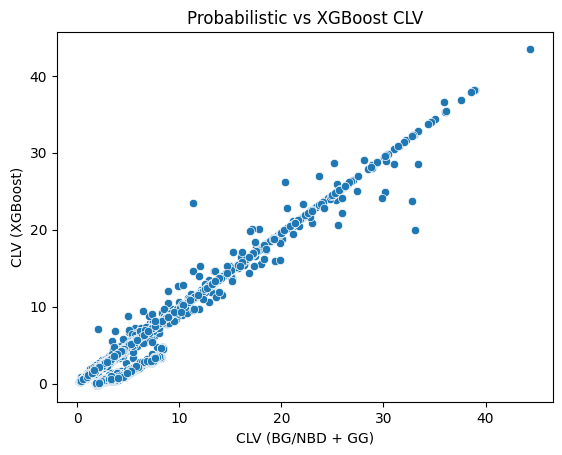

In [25]:
# Extract predictions from previous ML models if not already stored
comparison = xdata[['Customer ID', 'CLV_XGBoost', 'CLV_LightGBM', 'CLV_CatBoost']].copy()

# Merge with probabilistic CLV
comparison = comparison.merge(rfm[['expected_revenue_90D']], left_on='Customer ID', right_index=True)

# Rename for clarity
comparison = comparison.rename(columns={
    'expected_revenue_90D': 'CLV_Probabilistic'
})

# Correlation matrix
print("Correlation between models and probabilistic CLV:")
print(comparison.corr())

# Plot for XGBoost
sns.scatterplot(data=comparison, x='CLV_Probabilistic', y='CLV_XGBoost')
plt.title("Probabilistic vs XGBoost CLV")
plt.xlabel("CLV (BG/NBD + GG)")
plt.ylabel("CLV (XGBoost)")
plt.show()


In [26]:
# Merge all into a final table
final = xdata.merge(
    rfm[['expected_orders_90D', 'expected_aov', 'expected_revenue_90D']],
    left_on='Customer ID',
    right_index=True,
    how='left'
)

# Save final comparison table
final.to_csv("CLV_Full_Comparison.csv", index=False)
print("Saved: CLV_Full_Comparison.csv")


Saved: CLV_Full_Comparison.csv


📋 Error Summary Statistics:


,Abs_Error_XGBoost,Pct_Error_XGBoost,Abs_Error_LightGBM,Pct_Error_LightGBM,Abs_Error_CatBoost,Pct_Error_CatBoost
count,5215.000000,5215.000000,5215.000000,5215.000000,5215.000000,5215.000000
mean,1.343431,34.817387,1.379539,35.622477,1.375345,35.467274
std,1.482191,38.427351,1.498304,37.830936,1.517559,37.773442
min,0.000048,0.006151,0.000030,0.004092,0.000006,0.000620
25%,0.089468,1.970978,0.108590,2.685107,0.102750,2.558813
50%,0.315208,4.648848,0.404989,7.908586,0.397731,7.220799
75%,2.657815,77.764001,2.710137,75.736534,2.580498,79.526645
max,13.121905,250.800052,12.667324,159.638391,12.278816,130.334816


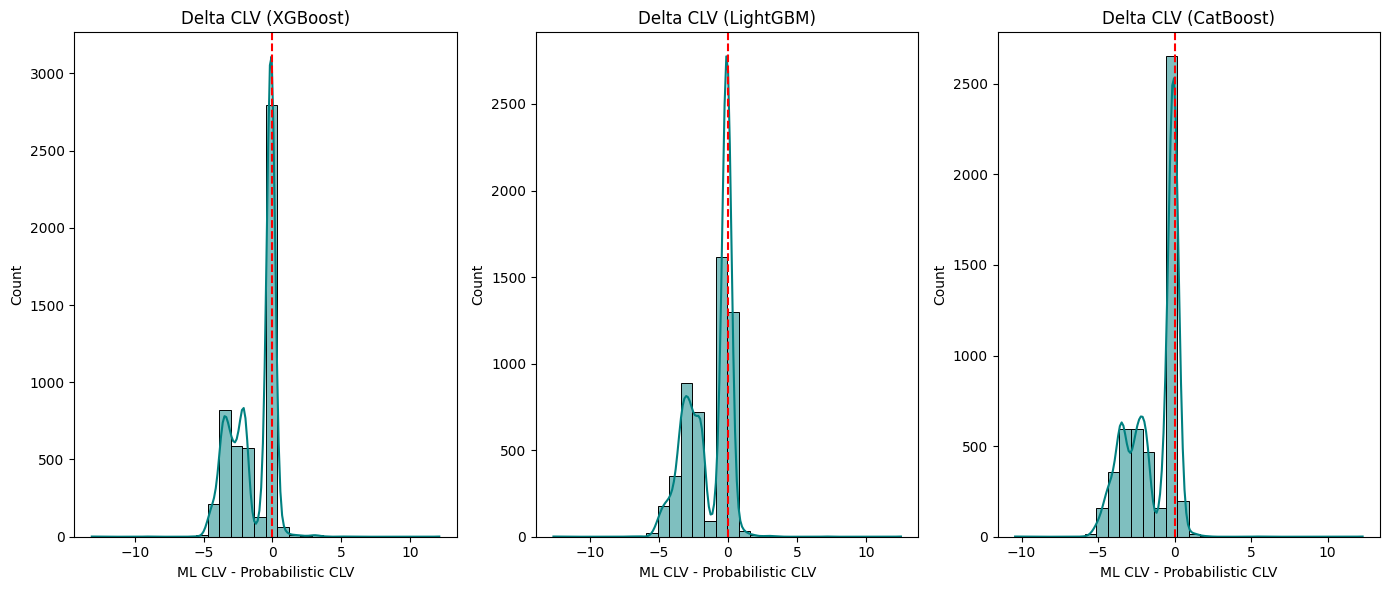

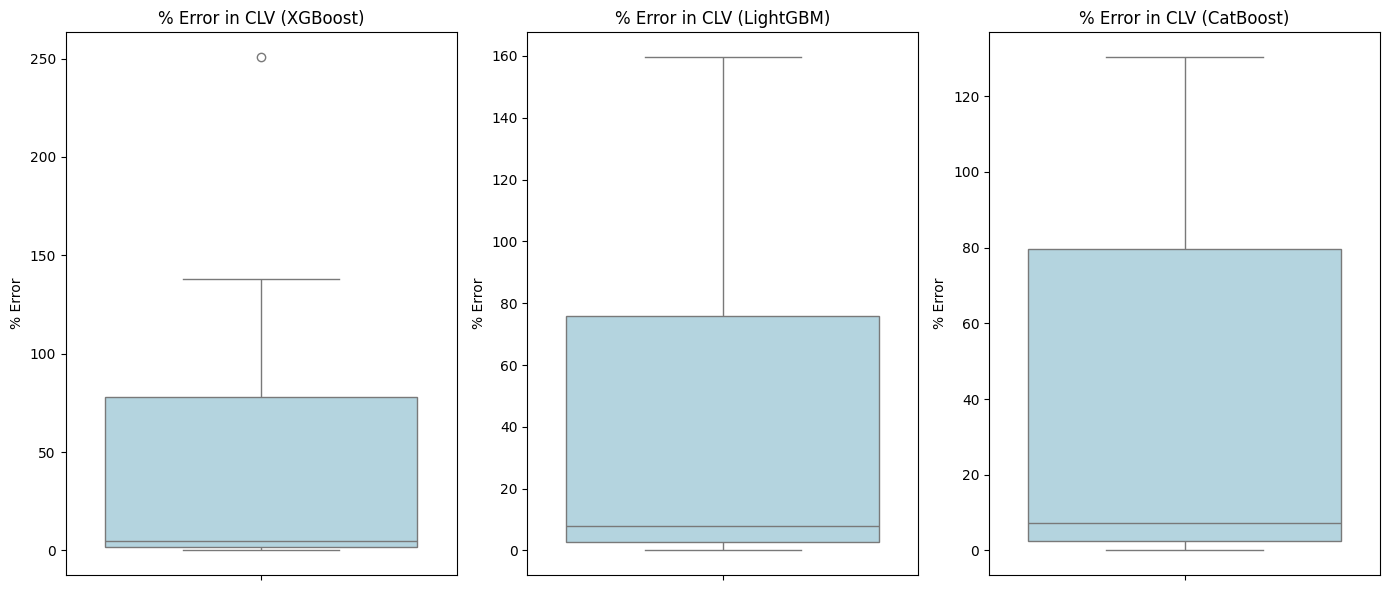

In [27]:
# 🧮 Step 1: Create delta (error) columns
comparison['Delta_XGBoost'] = comparison['CLV_XGBoost'] - comparison['CLV_Probabilistic']
comparison['Delta_LightGBM'] = comparison['CLV_LightGBM'] - comparison['CLV_Probabilistic']
comparison['Delta_CatBoost'] = comparison['CLV_CatBoost'] - comparison['CLV_Probabilistic']

# 🔍 Step 2: Calculate absolute error and percentage error
for model in ['XGBoost', 'LightGBM', 'CatBoost']:
    comparison[f'Abs_Error_{model}'] = comparison[f'Delta_{model}'].abs()
    comparison[f'Pct_Error_{model}'] = comparison[f'Abs_Error_{model}'] / (comparison['CLV_Probabilistic'] + 1e-8) * 100

# 📊 Step 3: Summary statistics
summary = comparison[[col for col in comparison.columns if 'Error' in col]].describe()
print("📋 Error Summary Statistics:")
display(summary)

# 📈 Step 4: Visualize delta distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
for i, model in enumerate(['XGBoost', 'LightGBM', 'CatBoost']):
    plt.subplot(1, 3, i+1)
    sns.histplot(comparison[f'Delta_{model}'], kde=True, bins=30, color='teal')
    plt.title(f'Delta CLV ({model})')
    plt.xlabel('ML CLV - Probabilistic CLV')
    plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# 📉 Step 5: Visualize percentage error
plt.figure(figsize=(14, 6))
for i, model in enumerate(['XGBoost', 'LightGBM', 'CatBoost']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=comparison[f'Pct_Error_{model}'], color='lightblue')
    plt.title(f'% Error in CLV ({model})')
    plt.ylabel('% Error')

plt.tight_layout()
plt.show()
